In [1]:
print("ljnkjn")

ljnkjn


In [2]:
%pwd
import os
os.chdir("../")
#Just went one step bcakword with this directory....

%pwd

'd:\\mlops\\Crypto_Guardian'

In [16]:
import pandas as pd

df = pd.read_csv("artifacts\data_cleaning\data.csv")

df.head()

,Unnamed: 0,comment_id,video_id,text,Label,Score
0,0,Ugxwyq6x4LC7cSNn2N14AaABAg,3JZ_D3ELwOQ,super kangaroo jacked,NEGATIVE,0.990524
1,1,Ugzifx090RDuQCZf7Ol4AaABAg,3JZ_D3ELwOQ,arkansas don39t play man,NEGATIVE,0.976599
2,2,UgxcfPMtewKBQ4BGt9l4AaABAg,3JZ_D3ELwOQ,kangaroo listens nba young boy,POSITIVE,0.968622
3,3,UgzeB8b41WQO5wtLUvx4AaABAg,3JZ_D3ELwOQ,whos watching 2001,POSITIVE,0.996961
4,4,UgxXmi7tm2DwumfZpMd4AaABAg,3JZ_D3ELwOQ,ray making new show youtube made recap 3 video...,NEGATIVE,0.981149


In [17]:
df.columns

Index(['Unnamed: 0', 'comment_id', 'video_id', 'text', 'Label', 'Score'], dtype='object')

In [18]:
df.drop(columns=['Unnamed: 0', 'comment_id', 'video_id'],inplace=True)

In [19]:
df.head()

,text,Label,Score
0,super kangaroo jacked,NEGATIVE,0.990524
1,arkansas don39t play man,NEGATIVE,0.976599
2,kangaroo listens nba young boy,POSITIVE,0.968622
3,whos watching 2001,POSITIVE,0.996961
4,ray making new show youtube made recap 3 video...,NEGATIVE,0.981149


In [13]:
import sys

def generate_eda_report(self, report_path="eda_report.txt"):
        """Saves DataFrame summary and statistics to a text file."""
        
        with open(report_path, 'w', encoding='utf-8') as f:
            f.write("="*50 + "\n")
            f.write("       DEEP EDA REPORT - CRYPTO GUARDIAN\n")
            f.write("="*50 + "\n\n")

            # 1. Dataset Shape
            f.write(f"Dataset Shape: {df.shape}\n")
            f.write("-" * 30 + "\n")

            # 2. Info (Thoda tricky hai isliye 'buf' use karenge)
            f.write("\n1. DATASET INFO:\n")
            import io
            buffer = io.StringIO()
            df.info(buf=buffer)
            f.write(buffer.getvalue())
            f.write("-" * 30 + "\n")

            # 3. Statistical Summary (Describe)
            f.write("\n2. STATISTICAL SUMMARY:\n")
            f.write(df.describe(include='all').to_string())
            f.write("\n" + "-" * 30 + "\n")

            # 4. Null Values
            f.write("\n3. NULL VALUES COUNT:\n")
            f.write(df.isnull().sum().to_string())
            f.write("\n" + "-" * 30 + "\n")

            # 5. Duplicate Rows
            f.write(f"\n4. DUPLICATE ROWS: {df.duplicated().sum()}\n")
            
            f.write("\n" + "="*50 + "\n")
            f.write("REPORT GENERATED SUCCESSFULLY\n")
            
        print(f"Bhai, EDA report save ho gayi hai yahan: {report_path}")

In [14]:
generate_eda_report("eda_report.txt")

Bhai, EDA report save ho gayi hai yahan: eda_report.txt


In [26]:
df.isnull().sum()

text     28
Label     0
Score     0
dtype: int64

In [27]:
df[df['text'].isnull()]

,text,Label,Score
67,NaN,NEGATIVE,0.793967
152,NaN,POSITIVE,0.748121
170,NaN,NEGATIVE,0.993637
173,NaN,POSITIVE,0.851397
180,NaN,POSITIVE,0.904299
270,NaN,POSITIVE,0.695793
289,NaN,POSITIVE,0.968902
331,NaN,POSITIVE,0.748121
431,NaN,POSITIVE,0.748121
514,NaN,POSITIVE,0.748121


In [30]:
df.dropna(inplace=True)

In [31]:
df.isnull().sum()

text     0
Label    0
Score    0
dtype: int64

In [34]:
df[df.duplicated()]

,text,Label,Score
77,deez nuts,POSITIVE,0.511533
160,even fuck bro,NEGATIVE,0.993693
165,rays first 3 video called,NEGATIVE,0.997681
188,even fuck bro,NEGATIVE,0.993693
223,lol,NEGATIVE,0.943818
...,...,...,...
2002,hi,POSITIVE,0.998327
2014,lol,NEGATIVE,0.943818
2020,lol,NEGATIVE,0.943818
2042,first,POSITIVE,0.997754


In [58]:
df.drop_duplicates(inplace=True)

In [59]:
df.shape

(1958, 7)

In [62]:
df.duplicated().sum()

np.int64(0)

<Axes: xlabel='count', ylabel='Label'>

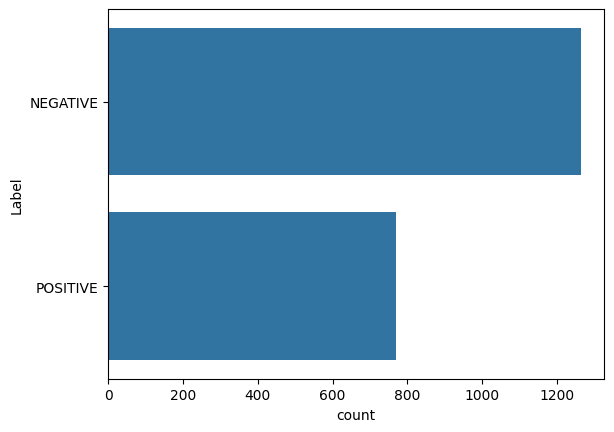

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(df['Label'])

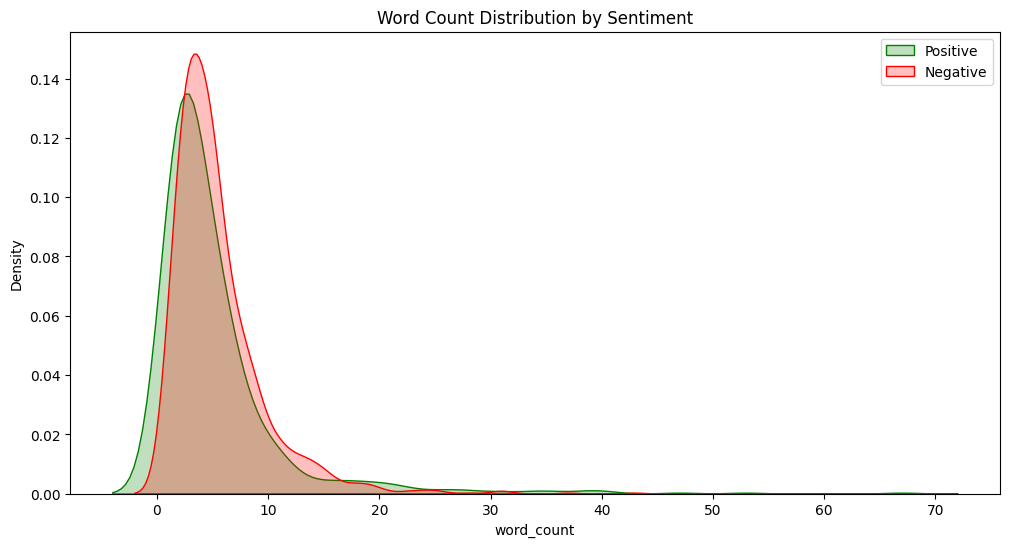

In [44]:
df["char_len"] = df["text"].astype(str).apply(len)
df["word_len"] = df["text"].astype(str).str.split().apply(len)

plt.figure(figsize=(12, 6))
sns.kdeplot(df[df['Label']=='POSITIVE']['word_count'], fill=True, color="green", label="Positive")
sns.kdeplot(df[df['Label']=='NEGATIVE']['word_count'], fill=True, color="red", label="Negative")
plt.title("Word Count Distribution by Sentiment")
plt.legend()
plt.show()

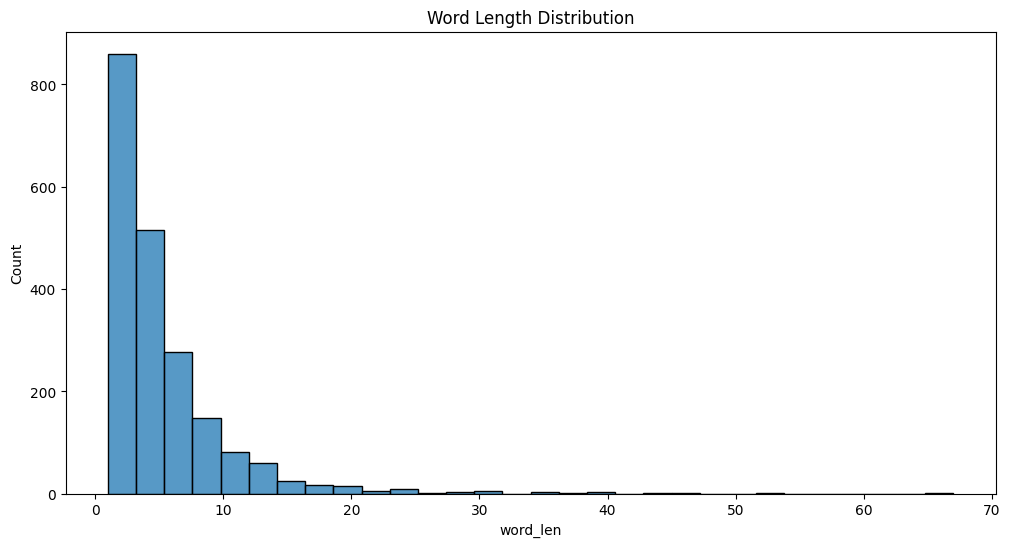

In [45]:
plt.figure(figsize=(12, 6))
sns.histplot(df["word_len"], bins=30)
plt.title("Word Length Distribution")
plt.show()

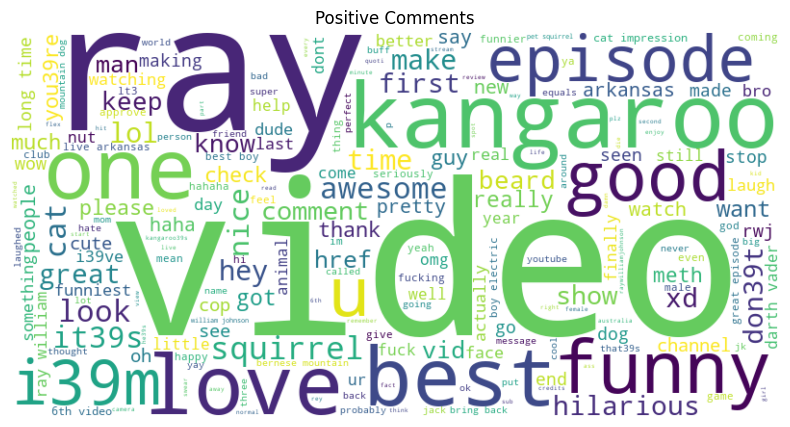

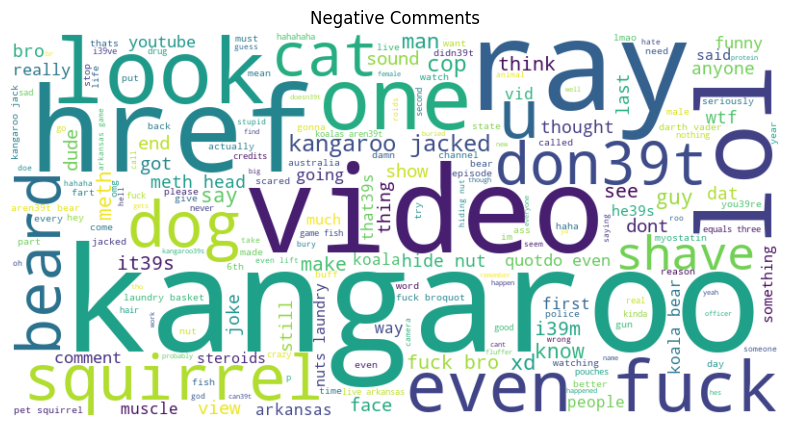

In [48]:
from wordcloud import WordCloud

def plot_wordcloud(text, title):
    wc = WordCloud(width=800, height=400, background_color='white').generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.title(title)
    plt.axis('off')
    plt.show()

# Positive WordCloud
plot_wordcloud(' '.join(df[df['Label']=='POSITIVE']['text']), "Positive Comments")
# Negative WordCloud
plot_wordcloud(' '.join(df[df['Label']=='NEGATIVE']['text']), "Negative Comments")

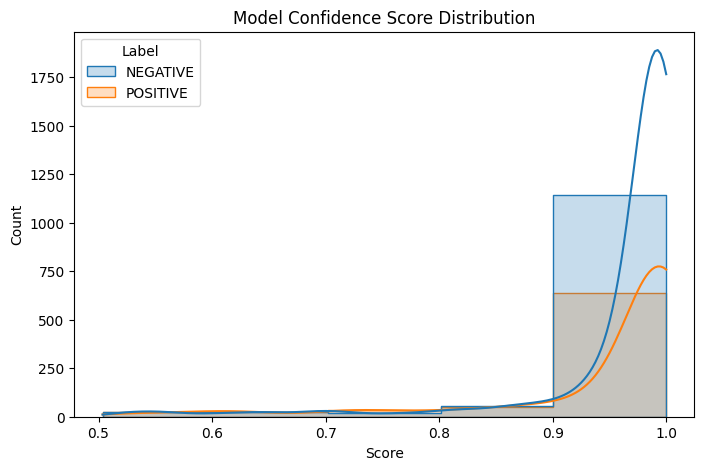

In [54]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="Score", hue="Label", kde=True, element="step", bins=5)
plt.title("Model Confidence Score Distribution")
plt.show()

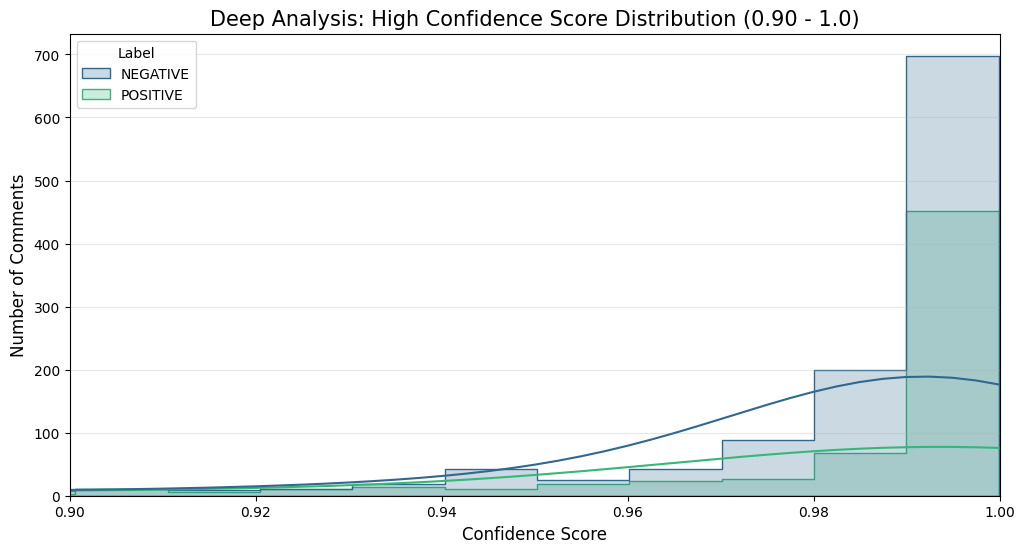

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))

# Zooming in on the high-confidence area (0.90 to 1.0)
sns.histplot(data=df, x="Score", hue="Label", kde=True,
             element="step", palette="viridis", bins=50)

# X-axis ko 0.9 se start karo taaki detail dikhe
plt.xlim(0.90, 1.0)

plt.title("Deep Analysis: High Confidence Score Distribution (0.90 - 1.0)", fontsize=15)
plt.xlabel("Confidence Score", fontsize=12)
plt.ylabel("Number of Comments", fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.show()

In [5]:
%pwd
import os
os.chdir("../")
#Just went one step bcakword with this directory....

%pwd

'd:\\mlops\\Crypto_Guardian'

In [3]:
from dataclasses import dataclass
from pathlib import Path

@dataclass
class DataReportConfig:
    root_dir: Path
    data_path: Path 
    report_path: Path

In [6]:
from src.Crypto.constants import *
from src.Crypto.utils.helper import read_yaml,create_directories
from src.Crypto import logger

class ConfigurationManager:
    def __init__(self,config_file_path=CONFIG_FILE_PATH,
                      params_file_path = PARAMS_FILE_PATH,
                      schema_file_path = SCHEMA_FILE_PATH):
        self.config =read_yaml( config_file_path)
        self.parmas = read_yaml(params_file_path)
        self.schema = read_yaml(schema_file_path)
        
        # create_directories([self.config.artifacts_root])
        logger.debug(f"Till Now all the Yaml Files are Read Sucessfully...✅")
    def get_data_report(self)->DataReportConfig:
        config = self.config.data_report
        create_directories([config.root_dir])
        
        data_report_config = DataReportConfig(
            root_dir=config.root_dir,
            data_path= config.data_path,
            report_path = config.report_path
        )
        logger.debug("get_data_ngestion is working compeletely fine...✅")
        return data_report_config


In [7]:

from src.Crypto import logger
import feedparser
import pandas as pd
from transformers import pipeline
import torch
from sources import Links,links
import sqlite3
from googleapiclient.discovery import build
from dotenv import load_dotenv
import sys

class DataReportComponent:
    def __init__(self,config: DataReportConfig):
        self.config = config
        self.df = pd.read_csv(self.config.data_path)
        self.df.drop(columns=['Unnamed: 0'],inplace=True)
        
        
    def generate_eda_report(self, report_path="data_report.txt"):
        """Saves DataFrame summary and statistics to a text file."""
        
        with open(report_path, 'w', encoding='utf-8') as f:
            f.write("="*50 + "\n")
            f.write("       DEEP EDA REPORT - CRYPTO GUARDIAN\n")
            f.write("="*50 + "\n\n")

            # 1. Dataset Shape
            f.write(f"Dataset Shape: {self.df.shape}\n")
            
            f.write("-" * 30 + "\n")

            # 2. Info (Thoda tricky hai isliye 'buf' use karenge)
            f.write("\n1. DATASET INFO:\n")
            import io
            buffer = io.StringIO()
            self.df.info(buf=buffer)
            f.write(buffer.getvalue())
            f.write("-" * 30 + "\n")

            # 3. Statistical Summary (Describe)
            f.write("\n2. STATISTICAL SUMMARY:\n")
            f.write(self.df.describe(include='all').to_string())
            f.write("\n" + "-" * 30 + "\n")

            # 4. Null Values
            f.write("\n3. NULL VALUES COUNT:\n")
            f.write(self.df.isnull().sum().to_string())
            f.write("\n" + "-" * 30 + "\n")

            # 5. Duplicate Rows
            f.write(f"\n4. DUPLICATE ROWS: {self.df.duplicated().sum()}\n")
            
            f.write("\n" + "="*50 + "\n")
            f.write("REPORT GENERATED SUCCESSFULLY\n")
            
        print(f"Bhai, EDA report save ho gayi hai yahan: {report_path}")
        logger.info(f"Bhai, EDA report save ho gayi hai yahan: {report_path}")
    
    def data_report(self):
        self.generate_eda_report(self.config.report_path)
        logger.info("Data Report Generated Sucessfully...✅")
    

C:\Users\sahil\AppData\Roaming\Python\Python310\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
d:\mlops\Crypto_Guardian\venv\lib\site-packages\google\api_core\_python_version_support.py:273: FutureWarning: You are using a Python version (3.10.11) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


In [10]:
try:
    cfm = ConfigurationManager()
    data_report = cfm.get_data_report()
    data_report_component = DataReportComponent(data_report)
    
    data_report_component.generate_eda_report()
    data_report_component.data_report()
    # data_ingestion_component.save_comments()
    logger.info("Pipeline Ran Sucessfully...✅")
except Exception as e:
    logger.error("Pipeline Error...❌")
    raise e


[05-05-2026 07:02:29 PM - helper - INFO - Yaml File :config\config.yaml Read Sucessfully✅]
[05-05-2026 07:02:29 PM - helper - INFO - Yaml File :params.yaml Read Sucessfully✅]
[05-05-2026 07:02:29 PM - helper - INFO - Yaml File :schema.yaml Read Sucessfully✅]
[05-05-2026 07:02:29 PM - helper - INFO - Folder Created Sucessfully: artifacts/data_report]
Bhai, EDA report save ho gayi hai yahan: data_report.txt
[05-05-2026 07:02:29 PM - 1243846332 - INFO - Bhai, EDA report save ho gayi hai yahan: data_report.txt]
Bhai, EDA report save ho gayi hai yahan: artifacts/data_report/data_report.txt
[05-05-2026 07:02:29 PM - 1243846332 - INFO - Bhai, EDA report save ho gayi hai yahan: artifacts/data_report/data_report.txt]
[05-05-2026 07:02:29 PM - 1243846332 - INFO - Data Report Generated Sucessfully...✅]
[05-05-2026 07:02:29 PM - 3587334746 - INFO - Pipeline Ran Sucessfully...✅]


In [ ]:
Bhai config yaaml banan padega bhai 

eda report

1. data to be acessed that csv file
2. foler to create and save the charts
